# Unsupervised model: Local Outlier Factor

This notebook follows a simple unsupervised setup.

- **train** = rows where `fraud == "unknown"`
- **test** = rows where `fraud == "fraud"`
- the label is only used to split the data and check the results later
- the model is trained **without** using the label as an input feature

So this is not a regular supervised classification problem.

What I want to check here is:

1. can Local Outlier Factor learn the local density pattern of the `unknown` data?
2. after fitting on that `unknown` set, do the `fraud` rows appear isolated enough from their neighbors to be flagged as anomalous?

In this notebook, LOF is used as an anomaly detection method based on local neighborhood density rather than global clustering structure.

For evaluation, the main focus is whether the known fraud cases receive strong outlier signals compared with the general unlabeled population.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from scipy import sparse

from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import OneClassSVM

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

## 1. Config

In [2]:
DATA_PATH = "fraud_data_encoded_v2.csv"

LABEL_COL = "fraud"
TRAIN_LABEL = "unknown"
TEST_LABEL = "fraud"

RANDOM_STATE = 42
KMEANS_K = 3
KMEANS_DISTANCE_QUANTILE = 0.99

OCSVM_KERNEL = "rbf"
OCSVM_NU = 0.05
OCSVM_GAMMA = "scale"

MAX_CATEGORICAL_LEVELS = 30
MAX_CATEGORICAL_RATIO = 0.05
MAX_MISSING_RATE = 0.98
SVD_MAX_COMPONENTS = 50

FLAG_MAPPINGS = {
    "ocr_tampering_flag": {"yes": 1, "no": 0},
    "front_liveness_fakeprint": {"true": 1, "false": 0},
    "back_liveness_fakeprint": {"true": 1, "false": 0},
    "front_object_liveness": {"success": 1, "failure": 0},
    "back_object_liveness": {"success": 1, "failure": 0},
    "liveness3d_object_liveness": {"success": 1, "failure": 0},
}

NUMERIC_COLS = ["tampering_flag", "year", "month", "day"]

DROP_NAME_KEYWORDS = [
    "uuid",
    "hash",
    "embedding",
    "image",
    "img",
    "photo",
    "avatar",
    "base64",
    "filepath",
    "filename",
    "sessionid",
]

MANUAL_DROP_COLS = [
    "tokenid",
    "ocr_cccd",
    "finger_print",
    "client_session",
    "facecompare_uuid",
    "liveness3d_uuid",
    "geolite_ipaddress",
]

## 2. Helpers

Nothing fancy here. I just keep the preprocessing and feature selection in a few small functions so the notebook stays readable.

In [3]:
def normalize_text(series):
    return series.astype("string").str.strip().str.lower()


def safe_map(series, mapping):
    return normalize_text(series).map(mapping)


def preprocess_data(df):
    data = df.copy()

    for col, mapping in FLAG_MAPPINGS.items():
        if col in data.columns:
            data[col] = safe_map(data[col], mapping)

    for col in NUMERIC_COLS:
        if col in data.columns:
            data[col] = pd.to_numeric(data[col], errors="coerce")

    if LABEL_COL in data.columns:
        data["target"] = normalize_text(data[LABEL_COL]).map({
            TRAIN_LABEL: 0,
            TEST_LABEL: 1,
        })

    return data


def pick_feature_columns(df, label_col):
    keep_cols = []
    dropped_rows = []

    for col in df.columns:
        if col in {label_col, "target"}:
            dropped_rows.append({"column": col, "reason": "label"})
            continue

        series = df[col]
        nunique = series.nunique(dropna=False)
        missing_rate = series.isna().mean()
        unique_ratio = nunique / len(df)

        if col in MANUAL_DROP_COLS:
            dropped_rows.append({"column": col, "reason": "manual_drop"})
            continue

        if any(keyword in col.lower() for keyword in DROP_NAME_KEYWORDS):
            dropped_rows.append({"column": col, "reason": "name_rule"})
            continue

        if nunique <= 1:
            dropped_rows.append({"column": col, "reason": "single_value"})
            continue

        if missing_rate >= MAX_MISSING_RATE:
            dropped_rows.append({"column": col, "reason": "too_many_missing"})
            continue

        if pd.api.types.is_numeric_dtype(series):
            keep_cols.append(col)
            continue

        if nunique <= MAX_CATEGORICAL_LEVELS and unique_ratio <= MAX_CATEGORICAL_RATIO:
            keep_cols.append(col)
        else:
            dropped_rows.append({"column": col, "reason": "high_cardinality_text"})

    dropped_df = pd.DataFrame(dropped_rows).sort_values(["reason", "column"]).reset_index(drop=True)
    return keep_cols, dropped_df


def make_preprocessor(df, feature_cols):
    numeric_cols = [col for col in feature_cols if pd.api.types.is_numeric_dtype(df[col])]
    categorical_cols = [col for col in feature_cols if col not in numeric_cols]

    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, numeric_cols),
            ("cat", categorical_pipe, categorical_cols),
        ],
        remainder="drop",
    )

    return preprocessor, numeric_cols, categorical_cols


def make_dense_representation(X_train, X_test, max_components=50, random_state=42):
    if sparse.issparse(X_train):
        max_valid = min(X_train.shape[0] - 1, X_train.shape[1] - 1, max_components)

        if max_valid >= 2:
            svd = TruncatedSVD(n_components=max_valid, random_state=random_state)
            X_train_dense = svd.fit_transform(X_train)
            X_test_dense = svd.transform(X_test)

            scaler = StandardScaler()
            X_train_dense = scaler.fit_transform(X_train_dense)
            X_test_dense = scaler.transform(X_test_dense)

            info = {
                "used_svd": True,
                "n_components": max_valid,
                "input_dim": X_train.shape[1],
                "output_dim": X_train_dense.shape[1],
            }
            return X_train_dense, X_test_dense, info

        X_train_dense = X_train.toarray()
        X_test_dense = X_test.toarray()
    else:
        X_train_dense = np.asarray(X_train)
        X_test_dense = np.asarray(X_test)

    scaler = StandardScaler()
    X_train_dense = scaler.fit_transform(X_train_dense)
    X_test_dense = scaler.transform(X_test_dense)

    info = {
        "used_svd": False,
        "n_components": None,
        "input_dim": X_train_dense.shape[1],
        "output_dim": X_train_dense.shape[1],
    }
    return X_train_dense, X_test_dense, info


def plot_pca_clusters(X, cluster_labels, title):
    if X.shape[1] < 2:
        print("PCA plot skipped because the feature space is less than 2D.")
        return

    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    coords = pca.fit_transform(X)

    plt.figure(figsize=(8, 5))
    plt.scatter(coords[:, 0], coords[:, 1], c=cluster_labels, s=14, alpha=0.75)
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.show()


def distance_summary(train_dist, test_dist, quantiles=(0.95, 0.99, 1.00)):
    rows = []

    for q in quantiles:
        if q < 1.0:
            threshold = float(np.quantile(train_dist, q))
            label = f"q={q:.2f}"
        else:
            threshold = float(np.max(train_dist))
            label = "max(train)"

        train_flag = train_dist > threshold
        test_flag = test_dist > threshold

        rows.append({
            "threshold_rule": label,
            "threshold_value": threshold,
            "train_flagged_rate": float(train_flag.mean()),
            "test_flagged_rate": float(test_flag.mean()),
        })

    return pd.DataFrame(rows)


def show_hist(train_values, test_values, title, xlabel):
    plt.figure(figsize=(8, 4))
    plt.hist(train_values, bins=40, alpha=0.7, label="train: unknown")
    plt.hist(test_values, bins=40, alpha=0.7, label="test: fraud")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 3. Load the data and split it the way we agreed

The split is fully label-based, but the label does **not** go into the model features.

- train = all `unknown`
- test = all `fraud`

In [4]:
df_raw = pd.read_csv(DATA_PATH)
df = preprocess_data(df_raw)

label_counts = normalize_text(df[LABEL_COL]).value_counts(dropna=False).rename_axis(LABEL_COL).reset_index(name="count")
display(label_counts)

train_mask = normalize_text(df[LABEL_COL]) == TRAIN_LABEL
test_mask = normalize_text(df[LABEL_COL]) == TEST_LABEL

train_df = df.loc[train_mask].copy()
test_df = df.loc[test_mask].copy()

print(f"Full data shape  : {df.shape}")
print(f"Train shape      : {train_df.shape}  (all '{TRAIN_LABEL}')")
print(f"Test shape       : {test_df.shape}  (all '{TEST_LABEL}')")

,fraud,count
0,unknown,31293
1,fraud,39


Full data shape  : (31332, 46)
Train shape      : (31293, 46)  (all 'unknown')
Test shape       : (39, 46)  (all 'fraud')


## 4. Pick a usable feature set

I do **not** want to throw raw IDs, UUIDs, hash-like columns, image paths, or huge text-cardinality columns straight into the models.

So the feature selection below keeps things fairly conservative:

- keep numeric columns
- keep small categorical columns
- drop the label
- drop obviously leak-prone or ID-like fields
- drop columns that are nearly all missing

In [5]:
feature_cols, dropped_feature_info = pick_feature_columns(train_df, LABEL_COL)

print(f"Columns kept for modeling: {len(feature_cols)}")
print(f"Columns dropped         : {len(dropped_feature_info)}")

display(pd.DataFrame({"feature_col": feature_cols}).head(50))
display(dropped_feature_info.head(50))

if len(feature_cols) == 0:
    raise ValueError("No feature columns left after filtering. Please loosen the feature selection rules.")

Columns kept for modeling: 19
Columns dropped         : 27


,feature_col
0,req_path
1,req_timestamplog
2,res_timestamplog
3,ocr_tampering_flag
4,month
5,day
6,front_liveness_fakeprint
7,front_object_liveness
8,liveness_timestamplog_front
9,liveness_timestamplog_back


,column,reason
0,city,high_cardinality_text
1,flag_123456,high_cardinality_text
2,ipaddress,high_cardinality_text
3,ma_may,high_cardinality_text
4,os_version,high_cardinality_text
5,fraud,label
6,target,label
7,client_session,manual_drop
8,facecompare_uuid,manual_drop
9,finger_print,manual_drop


In [6]:
X_train_df = train_df[feature_cols].copy()
X_test_df = test_df[feature_cols].copy()

preprocessor, numeric_cols, categorical_cols = make_preprocessor(train_df, feature_cols)

X_train_pre = preprocessor.fit_transform(X_train_df)
X_test_pre = preprocessor.transform(X_test_df)

X_train_model, X_test_model, dim_info = make_dense_representation(
    X_train_pre,
    X_test_pre,
    max_components=SVD_MAX_COMPONENTS,
    random_state=RANDOM_STATE,
)

print("Numeric columns     :", len(numeric_cols))
print("Categorical columns :", len(categorical_cols))
print("Matrix info         :", dim_info)
print("Final train shape   :", X_train_model.shape)
print("Final test shape    :", X_test_model.shape)

Numeric columns     : 17
Categorical columns : 2
Matrix info         : {'used_svd': False, 'n_components': None, 'input_dim': 23, 'output_dim': 23}
Final train shape   : (31293, 23)
Final test shape    : (39, 23)


## Local Outlier Factor (LOF)

Compares the local density of each point to its neighbors.
Points surrounded by much denser regions get a high outlier score.

`novelty=True` is required to fit on train and score unseen test points separately.
`score_samples()` returns negative LOF — we negate it so higher = more anomalous.


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def recall_at_k(scores, pcts=(1, 5, 10, 20, 50, 100)):
    """scores: higher = more anomalous. test set = all fraud."""
    n = len(scores)
    rows = []
    for pct in pcts:
        k = max(1, int(np.ceil(n * pct / 100)))
        caught = len(np.argsort(scores)[-k:])
        rows.append({"top_%": pct, "k": k, "fraud_caught": caught,
                     "recall": round(caught / n, 4)})
    return pd.DataFrame(rows)

def plot_scores(train_scores, test_scores, title):
    # clip to 1st–99th percentile of train to avoid scale blowup
    lo = np.percentile(train_scores, 1)
    hi = np.percentile(train_scores, 99)
    t_clip = np.clip(train_scores, lo, hi)
    e_clip = np.clip(test_scores,  lo, hi)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(t_clip, bins=60, alpha=0.6, label="train: unknown")
    ax.hist(e_clip, bins=20, alpha=0.8, label="test: fraud (39)")
    ax.set_xlabel("Anomaly score  (higher = more suspicious, clipped 1–99 pct)")
    ax.set_ylabel("Count")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

def feature_importance(X_train, score_fn, feat_names, top_n=15, title=""):
    """
    3-panel feature importance:
      1. correlation with anomaly score
      2. permutation importance
      3. mean score per feature quartile (high vs low)
    score_fn: callable X -> 1-d anomaly score array (higher = more anomalous)
    """
    import matplotlib.pyplot as plt
    base_scores = score_fn(X_train)

    # 1. correlation
    corr = (pd.DataFrame(X_train, columns=feat_names)
              .assign(score=base_scores)
              .corr()["score"]
              .drop("score")
              .abs()
              .sort_values(ascending=False)
              .head(top_n))

    # 2. permutation importance
    rng = np.random.default_rng(42)
    deltas = np.zeros(X_train.shape[1])
    for i in range(X_train.shape[1]):
        Xp = X_train.copy(); rng.shuffle(Xp[:, i])
        deltas[i] = score_fn(Xp).mean() - base_scores.mean()
    perm_order = np.argsort(np.abs(deltas))[::-1][:top_n]

    # 3. mean feature value: top-5% anomaly vs rest
    threshold = np.percentile(base_scores, 95)
    flag = base_scores >= threshold
    df_fi = pd.DataFrame(X_train, columns=feat_names)
    spread = (df_fi[flag].mean() - df_fi[~flag].mean()).abs()
    top_spread = spread.sort_values(ascending=False).head(top_n).index.tolist()
    group_means = df_fi.assign(group=np.where(flag, "top-5% anomaly", "rest")).groupby("group").mean()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Feature importance — {title}", fontsize=12)

    # panel 1
    corr.plot.barh(ax=axes[0]); axes[0].invert_yaxis()
    axes[0].set_title("Correlation with anomaly score")
    axes[0].set_xlabel("|Pearson r|")

    # panel 2
    axes[1].barh(range(top_n), deltas[perm_order])
    axes[1].set_yticks(range(top_n))
    axes[1].set_yticklabels([feat_names[i] for i in perm_order], fontsize=7)
    axes[1].invert_yaxis(); axes[1].axvline(0, color="black", lw=0.8)
    axes[1].set_title("Permutation importance")
    axes[1].set_xlabel("Δ mean anomaly score")

    # panel 3
    group_means[top_spread].T.plot(kind="bar", ax=axes[2], width=0.6)
    axes[2].set_title("Mean feature value: top-5% anomaly vs rest")
    axes[2].set_xlabel(""); axes[2].set_ylabel("Mean (scaled)")
    axes[2].legend(bbox_to_anchor=(1.01, 1), loc="upper left")
    axes[2].tick_params(axis="x", labelsize=7); plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45, ha="right")

    plt.tight_layout()
    plt.show()

# feature names from preprocessor
try:
    feat_names = preprocessor.get_feature_names_out().tolist()
except Exception:
    feat_names = [f"f{i}" for i in range(X_train_model.shape[1])]


In [8]:
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=OCSVM_NU,
    novelty=True,   # must be True to score new data
    n_jobs=-1,
)
lof.fit(X_train_model)

lof_score_train = -lof.score_samples(X_train_model)
lof_score_test  = -lof.score_samples(X_test_model)
lof_pred_test   = lof.predict(X_test_model)

n_fraud = len(X_test_model)
caught  = int((lof_pred_test == -1).sum())
print(f"Train flagged : {(lof.predict(X_train_model) == -1).mean():.2%}")
print(f"Recall on {n_fraud} fraud: {caught}/{n_fraud} = {caught/n_fraud:.1%}")


Train flagged : 4.40%
Recall on 39 fraud: 39/39 = 100.0%


In [9]:
display(recall_at_k(lof_score_test))

,top_%,k,fraud_caught,recall
0,1,1,1,0.0256
1,5,2,2,0.0513
2,10,4,4,0.1026
3,20,8,8,0.2051
4,50,20,20,0.5128
5,100,39,39,1.0000


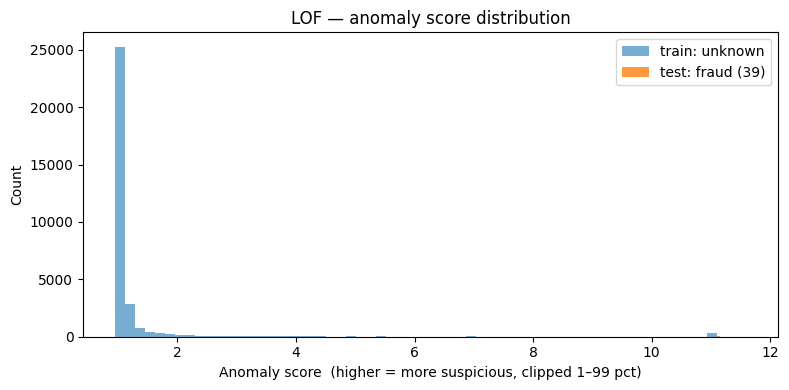

In [10]:
plot_scores(lof_score_train, lof_score_test, "LOF — anomaly score distribution")

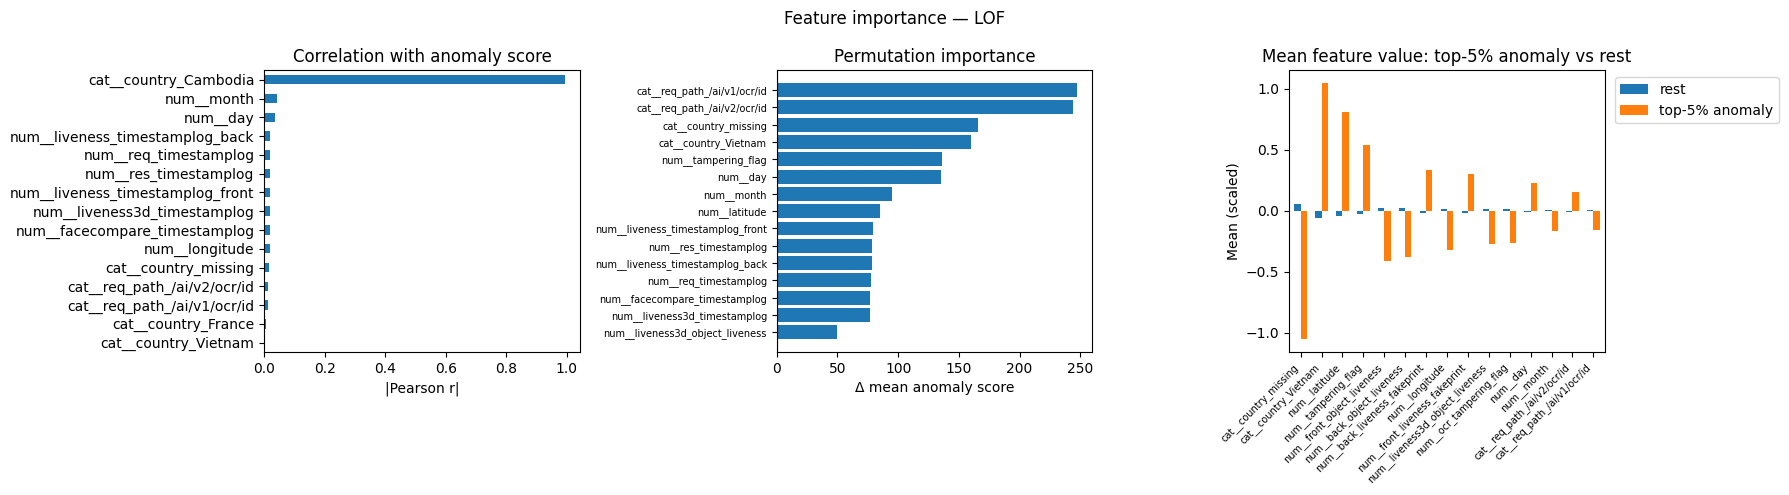

In [11]:
feature_importance(X_train_model, lambda X: -lof.score_samples(X), feat_names, title="LOF")